# Analiza logów - pipeline prezentacyjny

Ten notebook pokazuje krok po kroku: parser, filtry, liczenie fraz i statystyki błędów na godzinę.

In [1]:
from datetime import datetime
from domain.models import AnalysisConfig
from processing.analyzer import analyze_log_file
from report import result_to_dict
from visualization.plots import plot_errors_per_hour

## 1) Konfiguracja analizy

In [2]:
log_path = "data/raw/Hadoop_2k.log"

config = AnalysisConfig.from_iterables(
    phrases=("ERROR", "WARNING", "INFO"),
    levels=("ERROR", "WARNING"),
    date_from=datetime(2005, 1, 1, 0, 0, 0),
    date_to=datetime(2030, 1, 1, 0, 0, 0),
)

## 2) Uruchomienie analizy

In [3]:
result = analyze_log_file(log_path, config)
summary = result_to_dict(result)["summary"]
summary

{'total_lines': 2000,
 'parsed_lines': 2000,
 'parse_errors': 0,
 'matched_lines': 150}

## 3) Zliczenia fraz

In [4]:
result.phrase_counts

{'ERROR': 154, 'WARNING': 0, 'INFO': 6}

## 4) Przefiltrowane linie (pierwsze 10)

In [5]:
result.filtered_lines[:10]

['2015-10-18 18:04:11,034 ERROR [RMCommunicator Allocator] org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator: Container complete event for unknown container id container_1445144423722_0020_01_000012',
 '2015-10-18 18:06:01,840 ERROR [RMCommunicator Allocator] org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator: ERROR IN CONTACTING RM. ',
 '2015-10-18 18:06:03,856 ERROR [RMCommunicator Allocator] org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator: ERROR IN CONTACTING RM. ',
 '2015-10-18 18:06:05,934 ERROR [RMCommunicator Allocator] org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator: ERROR IN CONTACTING RM. ',
 '2015-10-18 18:06:07,950 ERROR [RMCommunicator Allocator] org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator: ERROR IN CONTACTING RM. ',
 '2015-10-18 18:06:09,966 ERROR [RMCommunicator Allocator] org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator: ERROR IN CONTACTING RM. ',
 '2015-10-18 18:06:11,997 ERROR [RMCommunicator Allocator] o

## 5) Błędy na godzinę

In [6]:
result.errors_per_hour

{'2015-10-18 18:00': 150}

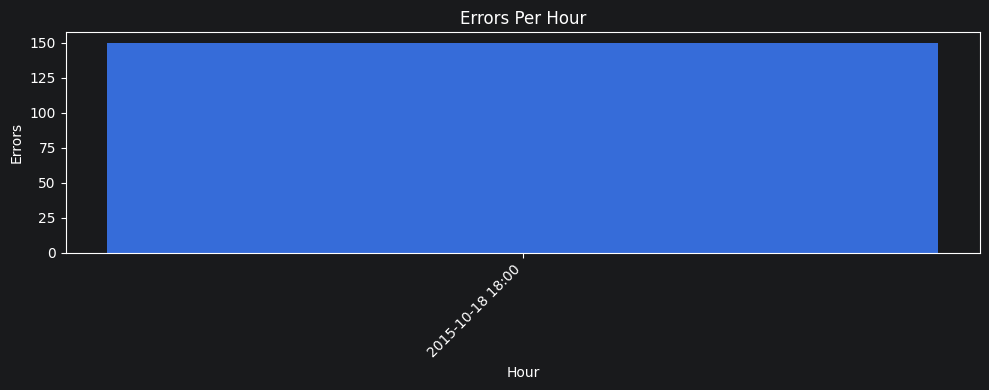

In [7]:
plot_errors_per_hour(result.errors_per_hour)